## Report on Students Performance

**Prepared by**: Kristityan Kirilov <br>
**Date**: 11.05.2026 <br>

### Introduction:

The purpose of this report is to examine the factors that affect students educational performance. <br>
Educational performance is important because it reflects students understanding, skills, and academic progress. <br>
This report discusses the main factors influencing performance and suggests ways to improve student achievement. <br>

### Factors Affecting Students Performance:

**Study Habits**: <br>
Good study habits play an important role in academic success. <br>
Students who manage their time well, complete assignments, and revise lessons regularly usually achieve better results. <br>

**Distractions**: <br>
Regular school attendance helps students understand lessons and participate in classroom activities. <br>
Students who miss classes frequently may struggle to keep up with their studies, that includes students also with jobs. <br>
We can use the free time spending to understand how it effects exams scores <br>

**Health and Lifestyle**: <br>
Healthy eating, enough sleep, and regular exercise help students concentrate better in class. <br>
Poor health habits may reduce academic performance. <br>

### Methodology:

We have datasets of two different sources <br>
Our mission is to build multiple predictions models that will show us what effects increase students performance and what decrease it <br>

Data:
1) Training data - used to build the prediction model <br>
2) Testing data - used to evaluate the model performance <br>

Sources:
1) Training Data - https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance
2) Testing Data - https://www.kaggle.com/datasets/aryan208/student-habits-and-academic-performance-dataset

### Setup:

In [201]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from utils.print import *

In [202]:
train_data_table = pd.read_csv("../data/train.csv")
test_data_table = pd.read_csv("../data/test.csv")

### Criteria:

In [203]:
SCORE_THRESHOLD = 50
ATTENDANCE_THRESHOLD = 30

def pass_criteria(table):
    pass_score = table['exam_score'] >= SCORE_THRESHOLD
    pass_attendance =table['attendance_percentage'] >= ATTENDANCE_THRESHOLD
    return pass_score & pass_attendance

train_data_table['pass'] = np.where(pass_criteria(train_data_table), 'Pass', 'Failed')
test_data_table['pass'] = np.where(pass_criteria(test_data_table), 'Pass', 'Failed')

### Study Habits:

Good study habits play an important role in academic success. <br>
Students who manage their time well, complete assignments, and revise lessons regularly usually achieve better results. <br>

#### Idea:

We want a make **linear dependency** between **study time** and **attendance** to see **how much the attendance improves the students score** <br>
We will use **linear regression model** with features - **study time** and **attendance** and target - **score**, to build score formula <br>
that determines what is the most important feature from the two for students perfomance

#### Data:

In [204]:
model_table = pd.DataFrame({
    "id": train_data_table["student_id"],
    "study_time": train_data_table["study_hours_per_day"],
    "attendance": train_data_table["attendance_percentage"],
    "score": train_data_table["exam_score"]
})

analyze_table = pd.DataFrame({
    "id": test_data_table["student_id"],
    "study_time": round(test_data_table["study_hours_per_day"]),
    "attendance": test_data_table["attendance_percentage"],
    "score": test_data_table["exam_score"]
})

#### Model:

In [205]:
# Define our sets of ids (I), features (X) and target (Y)
I = model_table['id']
X = model_table[['study_time', 'attendance']]
Y = model_table['score']

# Split the data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test, I_train, I_test = train_test_split(X, Y, I, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, Y_train)

# Save coefficients in separate variables
study_time_coef = model.coef_[0].round(2)
attendance_coef = model.coef_[1].round(2)
intercept = model.intercept_.round(2)

# Make predictions on the test set
Y_pred = np.clip(model.predict(X_test), None, 100)

# Calculate Mean Squared Error and R-squared score
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Create model table
model_data = pd.DataFrame({
    "id": I_test,
    "study_time": X_test["study_time"],
    "attendance": X_test["attendance"],
    "actual_score": Y_test,
    "predicted_score": Y_pred,
    "squared_error": (Y_test - Y_pred) ** 2
})

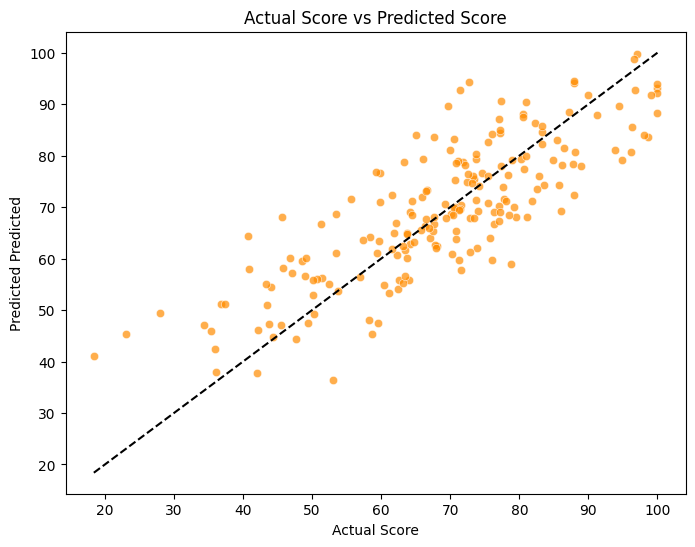

Model Data:
The model explains 66.2% of the variance in the score

Formula:
Score = 9.5 * study_time + 0.15 * attendance + 23.54

Data:
R-squared Score: 0.6623205873459584
Mean Squared Error: 86.59082652468683

Largest Errors:
        id  study_time  attendance  actual_score  predicted_score  \
526  S1526         2.8        95.9          40.7        64.357047   
265  S1265         0.6        79.9          18.4        41.091035   
959  S1959         3.2        95.1          45.7        68.037087   
327  S1327         0.9        89.2          23.1        45.319464   
737  S1737         5.9       100.0          72.7        94.405085   
938  S1938         1.2        97.7          28.0        49.429235   
277  S1277         5.9        89.0          71.4        92.773531   
998  S1998         5.4       100.0          69.7        89.656712   
254  S1254         2.5        78.6          78.8        58.942033   
261  S1261         5.1        81.6          65.1        84.078543   

     squared_

In [206]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=model_data["actual_score"], y=model_data["predicted_score"], color='darkorange', alpha=0.7)

# Add a diagonal line representing perfect predictions
max_val = max(model_data["actual_score"].max(), model_data["predicted_score"].max())
min_val = min(model_data["actual_score"].min(), model_data["predicted_score"].min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.xlabel('Actual Score')
plt.ylabel('Predicted Predicted')
plt.title('Actual Score vs Predicted Score')
plt.show()

print("Model Data:")
print(f"The model explains {r2*100:.1f}% of the variance in the score")
print()
print("Formula:")
print(f"Score = {study_time_coef} * study_time + {attendance_coef} * attendance + {intercept.round(2)}")
print()
print("Data:")
print(f"R-squared Score: {r2}")
print(f"Mean Squared Error: {mse}")
print()
print("Largest Errors:")
print(model_data.sort_values(by="squared_error", ascending=False).head(10))

#### Analyze:

In [207]:
analyze_data = pd.DataFrame({
    "id": analyze_table["id"],
    "study_time": analyze_table["study_time"],
    "attendance": analyze_table["attendance"],
    
    "actual_score" : analyze_table['score'],
    "predicted_score" : np.clip(model.predict(analyze_table[['study_time', 'attendance']]), None, 100)
})

mse = mean_squared_error(analyze_data["actual_score"], analyze_data["predicted_score"])
r2 = r2_score(analyze_data["actual_score"], analyze_data["predicted_score"])


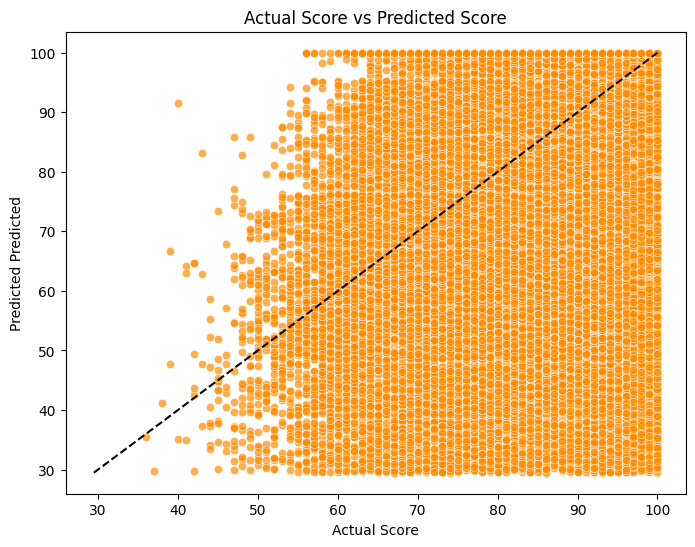

Analyze Data:
The model explains -366.0% of the variance in the score

Formula:
Score = 9.5 * study_time + 0.15 * attendance + 23.54

Data:
R-squared Score: -3.66035783885882
Mean Squared Error: 626.1708996570641


In [208]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=analyze_data["actual_score"], y=analyze_data["predicted_score"], color='darkorange', alpha=0.7)

# Add a diagonal line representing perfect predictions
max_val = max(analyze_data["actual_score"].max(), analyze_data["predicted_score"].max())
min_val = min(analyze_data["actual_score"].min(), analyze_data["predicted_score"].min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.xlabel('Actual Score')
plt.ylabel('Predicted Predicted')
plt.title('Actual Score vs Predicted Score')
plt.show()

print("Analyze Data:")
print(f"The model explains {r2*100:.1f}% of the variance in the score")
print()
print("Formula:")
print(f"Score = {study_time_coef} * study_time + {attendance_coef} * attendance + {intercept.round(2)}")
print()
print("Data:")
print(f"R-squared Score: {r2}")
print(f"Mean Squared Error: {mse}")

In [209]:
print("=== Training Data ===")
print(model_data[['study_time', 'attendance', 'actual_score']].describe().loc[['mean', 'min', 'max']])
print()
print("=== Analyze Data ===")
print(analyze_data[['study_time', 'attendance', 'actual_score']].describe().loc[['mean', 'min', 'max']])
print()
print("Formula:")
print(f"Score = {study_time_coef} * study_time + {attendance_coef} * attendance + {intercept}")

=== Training Data ===
      study_time  attendance  actual_score
mean       3.519      83.633        68.698
min        0.000      59.500        18.400
max        6.700     100.000       100.000

=== Analyze Data ===
      study_time  attendance  actual_score
mean      4.1727   69.967884      89.14135
min       0.0000   40.000000      36.00000
max      12.0000  100.000000     100.00000

Formula:
Score = 9.5 * study_time + 0.15 * attendance + 23.54


#### Conclusion:

The idea that **"more attendane means more score"** does not work  <br>

We can see from the **model data** that the **attendance** is important from the **mean** <br>
But in reality it does not increase the **score** that much from the **score formula**

We can see from **analyze data** that **attendance** is **"not bad"** but the **study time** is more important <br>
So we can assume that **attendance** does not matter that much <br>
What matter is how much **study time** the student does <br>

This is the reason that the students with extra activities and jobs manage to get big scores - they have more **study time** and less **attendance**  <br>

### Distractions:

Regular school attendance helps students understand lessons and participate in classroom activities. <br>
Students who miss classes frequently may struggle to keep up with their studies, that includes students also with jobs. <br>
We can also use the free time spending to understand how it effects exams scores <br>


#### Idea:

We want to get the **probability dependency** from **netflix**, **social**, **attendance**, **job** and how they effects students performane <br>
We will use **Gaussian Naive Bayes** with features - **netflix**, **social**, **attendance**, **job** and target - **pass** to determine things like **distraction** and **burnout**

#### Data:

In [210]:
model_table = pd.DataFrame({
    "id": train_data_table["student_id"],
    "netflix" : train_data_table["netflix_hours"],
    "social" : train_data_table["social_media_hours"],
    "attendance": train_data_table["attendance_percentage"],
    "job" : train_data_table["part_time_job"].str.lower().map({'no': 0, 'yes': 1}),
    "score": train_data_table['exam_score'],
    "pass": train_data_table['pass']
})

analyze_table = pd.DataFrame({
    "id": test_data_table["student_id"],
    "netflix" : test_data_table["netflix_hours"],
    "social" : test_data_table["social_media_hours"],
    "attendance": test_data_table["attendance_percentage"],
    "job" : test_data_table["part_time_job"].str.lower().map({'no': 0, 'yes': 1}),
    "score": test_data_table['exam_score'],
    "pass": test_data_table['pass']
})

#### Model:

In [211]:
# Define our features (X) and target (Y)
X = model_table[['netflix', 'social', 'attendance', 'job']]
Y = model_table['pass']

# Split the data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = GaussianNB()

# Train the model
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

matrix = confusion_matrix(Y_test, Y_pred, labels=['Pass', 'Failed'])

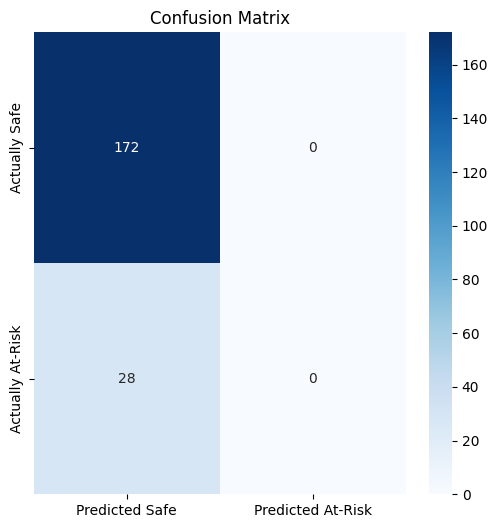

Model Data:
The model explains 86.00% of the variance in the score

Classification Report:
              precision    recall  f1-score   support

      Failed       0.00      0.00      0.00        28
        Pass       0.86      1.00      0.92       172

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200



In [212]:
plt.figure(figsize=(6,6))
plt.title('Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Truth')
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Safe', 'Predicted At-Risk'], yticklabels=['Actually Safe', 'Actually At-Risk'])
plt.show()

# Calculate overall accuracy
print("Model Data:")
print(f"The model explains {accuracy_score(Y_test, Y_pred) * 100:.2f}% of the variance in the score")
print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred, zero_division=0))

#### Analyze:

In [213]:
X_test = analyze_table[['netflix', 'social', 'attendance', 'job']]
Y_test = analyze_table['pass']

Y_pred = model.predict(X_test)

matrix = confusion_matrix(Y_test, Y_pred, labels=['Pass', 'Failed'])

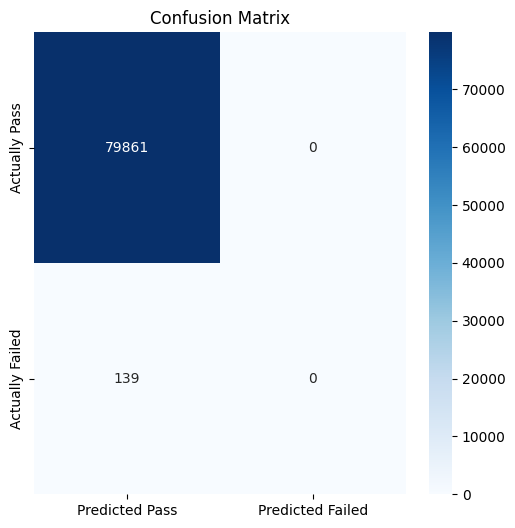

Model Data:
The model explains 99.83% of the variance in the score

Classification Report:
              precision    recall  f1-score   support

      Failed       0.00      0.00      0.00       139
        Pass       1.00      1.00      1.00     79861

    accuracy                           1.00     80000
   macro avg       0.50      0.50      0.50     80000
weighted avg       1.00      1.00      1.00     80000



In [214]:
plt.figure(figsize=(6,6))
plt.title('Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Truth')
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Pass', 'Predicted Failed'], yticklabels=['Actually Pass', 'Actually Failed'])
plt.show()

# Calculate overall accuracy
print("Model Data:")
print(f"The model explains {accuracy_score(Y_test, Y_pred) * 100:.2f}% of the variance in the score")
print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred, zero_division=0))

In [215]:
print("=== Training Data ===")
print(model_table[['netflix', 'social', 'attendance', 'job', 'score']].describe().loc[['mean', 'min', 'max']])
print()
print("=== Analyze Data ===")
print(analyze_table[['netflix', 'social', 'attendance', 'job', 'score']].describe().loc[['mean', 'min', 'max']])

=== Training Data ===
      netflix  social  attendance    job     score
mean   1.8197  2.5055     84.1317  0.215   69.6015
min    0.0000  0.0000     56.0000  0.000   18.4000
max    5.4000  7.2000    100.0000  1.000  100.0000

=== Analyze Data ===
       netflix    social  attendance       job      score
mean  1.997754  2.501366   69.967884  0.497563   89.14135
min   0.000000  0.000000   40.000000  0.000000   36.00000
max   4.000000  5.000000  100.000000  1.000000  100.00000
